importing Libraries


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import sqlite3
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


Module 1: Python Engineering & NumPy Vectorization (35 Mins)

• Task 1.1 — Memory-Efficient Batch Generator (OOP): Create a class BatchDataLoader that accepts feature matrix X and
target vector y with batch size batch_size. Implement a generator method get_batches(shuffle=True) using Python's yield
keyword so that full datasets are never duplicated in RAM.

In [2]:
class Batchdataloader :
    def __init__(self,x,y,batch_size):
        self.x = x
        self.y = y
        self.batch_size = batch_size

    def get_batches(self,shuffle = True):
        indices = np.arange(len(self.x))

        if shuffle :
            np.random.shuffle(indices)
        
        for start in range (0 , len(self.x) , self.batch_size):
            batch_indices = indices[start:start + self.batch_size]

            yield self.x[batch_indices] , self.y[batch_indices]


x = np.arange(200).reshape(100,2)
y = np.arange(100)

loader = Batchdataloader(x,y,batch_size=3)

for x_batch , y_batch in loader.get_batches():
    print("x batches:\n" , x_batch)
    print("y batches:\n" , y_batch)

x batches:
 [[108 109]
 [148 149]
 [ 88  89]]
y batches:
 [54 74 44]
x batches:
 [[18 19]
 [62 63]
 [90 91]]
y batches:
 [ 9 31 45]
x batches:
 [[118 119]
 [  2   3]
 [110 111]]
y batches:
 [59  1 55]
x batches:
 [[114 115]
 [162 163]
 [104 105]]
y batches:
 [57 81 52]
x batches:
 [[146 147]
 [ 64  65]
 [172 173]]
y batches:
 [73 32 86]
x batches:
 [[166 167]
 [170 171]
 [190 191]]
y batches:
 [83 85 95]
x batches:
 [[ 12  13]
 [164 165]
 [ 82  83]]
y batches:
 [ 6 82 41]
x batches:
 [[ 6  7]
 [46 47]
 [22 23]]
y batches:
 [ 3 23 11]
x batches:
 [[ 66  67]
 [130 131]
 [ 14  15]]
y batches:
 [33 65  7]
x batches:
 [[188 189]
 [156 157]
 [120 121]]
y batches:
 [94 78 60]
x batches:
 [[178 179]
 [ 24  25]
 [192 193]]
y batches:
 [89 12 96]
x batches:
 [[ 38  39]
 [ 40  41]
 [152 153]]
y batches:
 [19 20 76]
x batches:
 [[98 99]
 [76 77]
 [72 73]]
y batches:
 [49 38 36]
x batches:
 [[144 145]
 [198 199]
 [ 54  55]]
y batches:
 [72 99 27]
x batches:
 [[122 123]
 [ 48  49]
 [ 60  61]]
y batc

• Task 1.2 — Vectorized Pairwise Distance Matrix: Given two 2D arrays A of shape (M, D) and B of shape (N, D), implement
a function pairwise_euclidean_distance(A, B) using NumPy broadcasting in a single line without any loops. Verify that its output
matches scipy.spatial.distance.cdist(A, B).

In [3]:
A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

B = np.array([
    [1, 1],
    [4, 5]
])



def pairwise_euclidean_distance(A, B):
    return np.sqrt(np.sum(A**2, axis=1, keepdims=True) - 2 * np.dot(A, B.T) + np.sum(B**2, axis=1))

result = pairwise_euclidean_distance(A, B)
print(result)
expected = cdist(A, B)


print(np.allclose(result, expected))

[[1.         4.24264069]
 [3.60555128 1.41421356]
 [6.40312424 1.41421356]]
True


• Task 1.3 — Numerical Benchmark: Benchmark your vectorized function against a nested Python loop implementation for
M=500, N=500, D=50 using %timeit. Document the exact speedup factor (expected 50x–200x).

In [4]:
M = 500
N = 500
D = 50

A = np.random.rand(M, D)
B = np.random.rand(N, D)

print(A.shape)
print(B.shape)

(500, 50)
(500, 50)


In [5]:
def pairwise_euclidean_distance_loop(A, B):
    result = np.zeros((A.shape[0], B.shape[0]))

    for i in range(A.shape[0]):
        for j in range(B.shape[0]):
            diff = A[i] - B[j]
            result[i, j] = np.sqrt(np.sum(diff ** 2))

    return result



loop_result = pairwise_euclidean_distance_loop(A, B)
vectorized_result = pairwise_euclidean_distance(A, B)

loop_time = %timeit -o pairwise_euclidean_distance_loop(A, B)
vectorized_time = %timeit -o pairwise_euclidean_distance(A, B)

speedup = loop_time.best / vectorized_time.best

print(np.allclose(loop_result, vectorized_result))

print(speedup)

1.08 s ± 55.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.14 ms ± 403 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
True
275.5433874316366


Module 2: Linear Algebra & Gradient Descent Optimization (40 Mins)

• Task 2.1 — Eigen-Decomposition & SVD Verification: Given matrix M = np.array([[4, 2], [1, 3]]), compute its eigenvalues
and eigenvectors using np.linalg.eig. Verify mathematically that M @ v = l * v for each pair. Next, perform SVD on M (U, S, Vt =
np.linalg.svd(M)) and reconstruct M from its singular components.

In [6]:
M = np.array([
    [4, 2],
    [1, 3]
])

eigenvalues, eigenvectors = np.linalg.eig(M)

for i in range(len(eigenvalues)):
    eigenvalue = eigenvalues[i]
    eigenvector = eigenvectors[:, i]

    left_side = M @ eigenvector
    right_side = eigenvalue * eigenvector

    print(f"\nEigenvalue {i + 1}: {eigenvalue}")
    print("M @ v:", left_side)
    print("λ * v:", right_side)
    print("Verified:", np.allclose(left_side, right_side))

print("\nEigenvalues:\n" , eigenvalues)
print("\nEigenvactors:\n", eigenvectors)


Eigenvalue 1: 5.0
M @ v: [4.47213595 2.23606798]
λ * v: [4.47213595 2.23606798]
Verified: True

Eigenvalue 2: 2.0
M @ v: [-1.41421356  1.41421356]
λ * v: [-1.41421356  1.41421356]
Verified: True

Eigenvalues:
 [5. 2.]

Eigenvactors:
 [[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]


In [7]:
U, S, Vt = np.linalg.svd(M)

Sigma = np.diag(S)
M_reconstructed = U @ Sigma @ Vt

print("U:\n" , U )
print("\nS:\n" , S)
print("\nVt:\n" ,Vt )
print("Reconstructed M:\n" , M_reconstructed)



U:
 [[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]

S:
 [5.11667274 1.95439508]

Vt:
 [[-0.76775173 -0.64074744]
 [-0.64074744  0.76775173]]
Reconstructed M:
 [[4. 2.]
 [1. 3.]]


• Task 2.2 — 2D Gradient Descent Optimization: Implement gradient descent from scratch to find the global minimum of the
bivariate function: f(x, y) = (x - 3)^2 + 2*(y + 2)^2.
• Analytically derive the gradient vector Ñf = [¶f/¶x, ¶f/¶y].
• Run optimization starting at (x0, y0) = (0, 0) with learning rate a = 0.1 for 50 steps.
• Plot the 2D contour lines of f(x, y) and overlay the step trajectory in Matplotlib.

In [8]:
x = 0.0
y = 0.0

learning_rate = 0.1
steps = 50

def f(x, y):
    return (x - 3)**2 + 2 * (y + 2)**2

def gradient(x, y):
    dx = 2 * (x - 3)
    dy = 4 * (y + 2)

    return np.array([dx, dy])

trajectory = [(x, y)]

for _ in range(steps):
    grad = gradient(x, y)

    x = x - learning_rate * grad[0]
    y = y - learning_rate * grad[1]

    trajectory.append((x, y))

print("Final x:", x)
print("Final y:", y)
print("Final function value:", f(x, y))

Final x: 2.9999571825692186
Final y: -1.9999999999838345
Final function value: 1.8333323787190758e-09


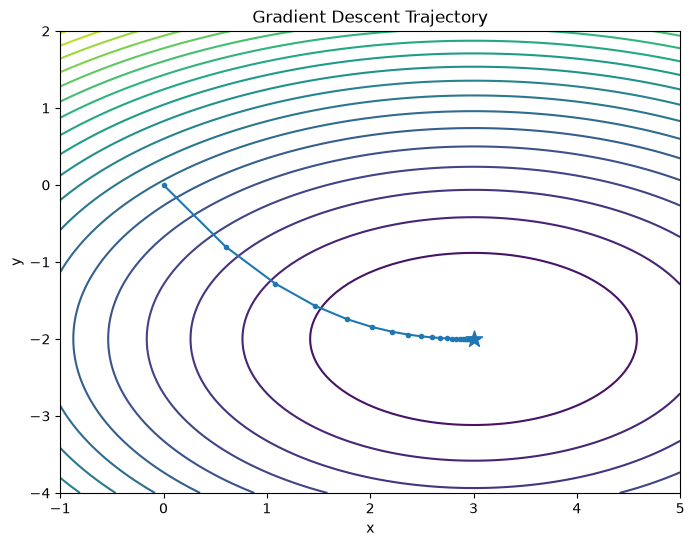

In [9]:
x_values = np.linspace(-1, 5, 100)
y_values = np.linspace(-4, 2, 100)

X, Y = np.meshgrid(x_values, y_values)

Z = f(X, Y)

plt.figure(figsize=(8, 6))

plt.contour(X, Y, Z, levels=20)

trajectory = np.array(trajectory)

plt.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    marker="o",
    markersize=3
)

plt.scatter(3, -2, marker="*", s=150)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Descent Trajectory")

plt.show()

Module 3: Probability, Statistics & SQL Analytical Drills (35 Mins)

• Task 3.1 — Bayes' Theorem & Monte Carlo Verification:
• Problem: A disease has 1% prevalence. A medical test has 95% sensitivity (True Positive Rate) and 5% false alarm rate
(False Positive Rate). What is the probability a patient has the disease given a positive test?
• Compute the exact posterior probability via Bayes' Rule formula.
• Write a 100,000-sample Monte Carlo simulation in NumPy to verify the theoretical result empirically.

In [10]:
np.random.seed(42)

n = 100_000

prevalence = 0.01
sensitivity = 0.95
false_positive_rate = 0.05

# Simulate whether each patient has the disease
disease = np.random.random(n) < prevalence

# Generate test results
test_positive = np.where(
    disease,
    np.random.random(n) < sensitivity,
    np.random.random(n) < false_positive_rate
)

# Calculate posterior probability
positive_and_disease = np.sum(test_positive & disease)
total_positive = np.sum(test_positive)

posterior_simulation = positive_and_disease / total_positive

print("Disease + positive:", positive_and_disease)
print("Total positive:", total_positive)
print("Simulated P(Disease | Positive):", posterior_simulation)
print("Percentage:", posterior_simulation * 100)

Disease + positive: 950
Total positive: 5802
Simulated P(Disease | Positive): 0.1637366425370562
Percentage: 16.37366425370562


• Task 3.2 — Two-Sample Hypothesis Testing: Generate two synthetic user group conversion rate samples (Group A:
mean=12.5%, std=3%, n=100; Group B: mean=14.2%, std=3.2%, n=100). Conduct a two-sample Student's t-test using
scipy.stats.ttest_ind. Formulate Null ($H_0$) and Alternative ($H_1$) hypotheses and state your conclusion at $\alpha = 0.05$.

In [11]:
np.random.seed(42)
alpha = 0.05

group_A = np.random.normal(
    loc=0.125,
    scale=0.03,
    size=100
)

group_B = np.random.normal(
    loc=0.142,
    scale=0.032,
    size=100
)

t_stat, p_value = stats.ttest_ind(group_A, group_B)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant difference between Group A and Group B.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence of a statistically significant difference.")

    

t-statistic: -5.091490069028248
p-value: 8.242185822866391e-07
Reject H0
There is a statistically significant difference between Group A and Group B.


• Task 3.3 — SQL Window Function Drill: In SQLite / Pandas SQL, write a query using window functions (OVER (PARTITION
BY ... ORDER BY ...)) to compute: (1) Running cumulative sum of sales, and (2) Row rank per department.

In [12]:
conn = sqlite3.connect(":memory:")

data = pd.DataFrame({
    "employee": ["A", "B", "C", "D", "E"],
    "department": ["IT", "IT", "IT", "HR", "HR"],
    "sale_date": ["2026-01-01", "2026-01-02", "2026-01-03", "2026-01-04", "2026-01-05"],
    "sales": [500, 300, 700, 400, 600]
})

data.to_sql("sales", conn, index=False, if_exists="replace")

query = """
SELECT
    employee,
    department,
    sale_date,
    sales,

    SUM(sales) OVER (
        ORDER BY sale_date
    ) AS running_sales,

    RANK() OVER (
        PARTITION BY department
        ORDER BY sales DESC
    ) AS department_rank

FROM sales;
"""

result = pd.read_sql_query(query, conn)

print(result)

  employee department   sale_date  sales  running_sales  department_rank
0        A         IT  2026-01-01    500            500                2
1        B         IT  2026-01-02    300            800                3
2        C         IT  2026-01-03    700           1500                1
3        D         HR  2026-01-04    400           1900                2
4        E         HR  2026-01-05    600           2500                1


Module 4: Day 21 Linear Regression Benchmark Sprint (40 Mins)

• Task 4.1 — Three-Way Implementation: Load the California Housing dataset (or a synthetic regression dataset with
n_samples=500, n_features=3). Train linear regression using three methods:


In [13]:
df = pd.read_csv("california_housing.csv")
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]

X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]




1. Closed-Form Solution: q = (X_b^T X_b)^(-1) X_b^T y (where X_b includes the bias column).

In [14]:
theta_normal = np.linalg.solve(
    X_train_b.T @ X_train_b,
    X_train_b.T @ y_train.to_numpy()
)

print("ClosedForm Solution:\n",theta_normal)

ClosedForm Solution:
 [ 2.20949087e+00  8.79915526e-01  1.69619588e-01  3.39813866e-02
  1.89607184e-03 -2.17350580e-03 -1.12160593e-01 -1.49141371e-01
 -1.70008580e-01]


2. Iterative Gradient Descent: Vectorized update q := q - a * (1/m) * X_b^T (X_b q - y).

In [15]:
theta_gd = np.zeros(X_train_b.shape[1])
learning_rate = 0.01
iterations = 5000

m = len(X_train_b)

# Gradient Descent
for i in range(iterations):
    gradients = (1 / m) * X_train_b.T @ (X_train_b @ theta_gd - y_train.to_numpy())
    
    theta_gd = theta_gd - learning_rate * gradients

print("Gradient Descent coefficients:\n",theta_gd)

Gradient Descent coefficients:
 [ 2.20949087e+00  8.79915526e-01  1.69619588e-01  3.39813866e-02
  1.89607184e-03 -2.17350580e-03 -1.12160593e-01 -1.49141371e-01
 -1.70008580e-01]


3. Scikit-Learn: LinearRegression().fit(X, y).

In [18]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

theta_sklearn = np.concatenate([
    [model.intercept_],
    model.coef_
])

print("Scikit-Learn coefficients:")
print(theta_sklearn)

Scikit-Learn coefficients:
[ 2.20949088e+00  8.79915526e-01  1.69619588e-01  3.39813866e-02
  1.89607184e-03 -2.17350580e-03 -1.12160593e-01 -1.49141371e-01
 -1.70008580e-01]


• Task 4.2 — Performance & Weight Parity: Create a Pandas summary table comparing the fitted weight coefficients ($w_1,
w_2, w_3$), intercept ($b$), and test metrics ($R^2$, RMSE, MAE) across all three methods. Confirm weights match within 4
decimal places.

In [20]:
y_pred_normal = X_test_b @ theta_normal

# Gradient Descent
y_pred_gd = X_test_b @ theta_gd

# Scikit-Learn
y_pred_sklearn = model.predict(X_test_scaled)


results = {
    "Normal Equation": {
        "R2": r2_score(y_test, y_pred_normal),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_normal)),
        "MAE": mean_absolute_error(y_test, y_pred_normal)
    },

    "Gradient Descent": {
        "R2": r2_score(y_test, y_pred_gd),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gd)),
        "MAE": mean_absolute_error(y_test, y_pred_gd)
    },

    "Scikit-Learn": {
        "R2": r2_score(y_test, y_pred_sklearn),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_sklearn)),
        "MAE": mean_absolute_error(y_test, y_pred_sklearn)
    }

}



In [21]:
metrics_table = pd.DataFrame(results).T

print("Performance Comparison:")
print(metrics_table.round(4))


feature_names = ["Intercept"] + list(X.columns)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Normal Equation": theta_normal,
    "Gradient Descent": theta_gd,
    "Scikit-Learn": theta_sklearn
})

print("\nCoefficient Comparison:")
print(coefficient_table.round(4))


normal_vs_gd = np.allclose(
    theta_normal,
    theta_gd,
    atol=1e-4
)

Performance Comparison:
                      R2    RMSE     MAE
Normal Equation   0.8383  0.4059  0.3193
Gradient Descent  0.8383  0.4059  0.3193
Scikit-Learn      0.8383  0.4059  0.3193

Coefficient Comparison:
      Feature  Normal Equation  Gradient Descent  Scikit-Learn
0   Intercept           2.2095            2.2095        2.2095
1      MedInc           0.8799            0.8799        0.8799
2    HouseAge           0.1696            0.1696        0.1696
3    AveRooms           0.0340            0.0340        0.0340
4   AveBedrms           0.0019            0.0019        0.0019
5  Population          -0.0022           -0.0022       -0.0022
6    AveOccup          -0.1122           -0.1122       -0.1122
7    Latitude          -0.1491           -0.1491       -0.1491
8   Longitude          -0.1700           -0.1700       -0.1700


In [22]:
normal_vs_sklearn = np.allclose(
    theta_normal,
    theta_sklearn,
    atol=1e-4
)

print("\nWeight Parity Check:")
print("Normal Equation vs Gradient Descent:", normal_vs_gd)
print("Normal Equation vs Scikit-Learn:", normal_vs_sklearn)


Weight Parity Check:
Normal Equation vs Gradient Descent: True
Normal Equation vs Scikit-Learn: True


• Task 4.3 — Coefficient Interpretation: Write 2–3 sentences interpreting the sign and magnitude of the top positive and
negative regression coefficients in terms of domain impact.

In [24]:
feature_coefficients = pd.Series(
    theta_sklearn[1:],
    index=X.columns
)

top_positive = feature_coefficients.idxmax()
top_positive_value = feature_coefficients.max()

top_negative = feature_coefficients.idxmin()
top_negative_value = feature_coefficients.min()

print("Top positive:", top_positive, top_positive_value)
print("Top negative:", top_negative, top_negative_value)



'''MedInc has the strongest positive impact (0.8799), 
while Longitude has the strongest negative impact (-0.1700).
 MedInc has a much stronger effect on predicted house value than Longitude.'''

Top positive: MedInc 0.8799155259271905
Top negative: Longitude -0.17000858018055004


'MedInc has the strongest positive impact (0.8799), \nwhile Longitude has the strongest negative impact (-0.1700).\n MedInc has a much stronger effect on predicted house value than Longitude.'